In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import preprocessing as pps
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import silhouette_score

In [2]:
data = pd.read_csv(r"../data/dataset.csv",index_col=0)

In [3]:
data_clean_2=pps.clean_data_2(data)
print(data.shape)
print(data_clean_2.shape)

(768, 8)
(708, 10)


In [4]:
data_clean_2.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Insuline_bool,SkinThickness_bool
0,6,148,72,35,0,33.6,0.627,50,0,1
1,1,85,66,29,0,26.6,0.351,31,0,1
2,8,183,64,0,0,23.3,0.672,32,0,0
3,1,89,66,23,94,28.1,0.167,21,1,1
5,5,116,74,0,0,25.6,0.201,30,0,0


In [5]:
colonnes_cluster=['Glucose','BloodPressure','BMI','DiabetesPedigreeFunction','Age']

Appliquer un scaler sur les données choisies

In [6]:
X=data_clean_2[colonnes_cluster]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### La méthode du coude
La méthode du coude est une technique visuelle utilisée pour choisir le nombre optimal de clusters (K) dans des algorithmes de clustering comme K-means. Elle repose sur l'analyse de l'inertie (somme des carrés des distances intra-cluster).

### La silhouette
La silhouette est une mesure qui évalue à quel point un objet (une donnée) est bien placé dans son cluster par rapport aux autres clusters. Elle aide à déterminer :

✅ La cohésion : À quel point les points d'un cluster sont proches entre eux.

✅ La séparation : À quel point les clusters sont distincts les uns des autres.

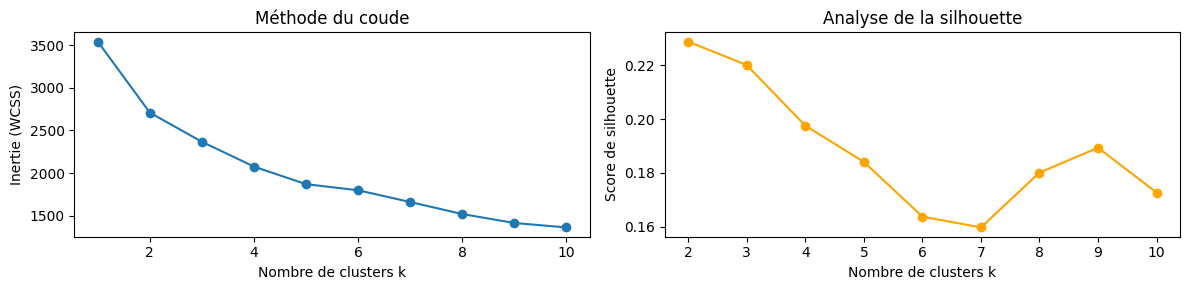

In [7]:

wcss = []
silhouette_scores = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

    # Calcul du score de silhouette
    if k>1:
        silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
        silhouette_scores.append(silhouette_avg)

# Création d'une figure avec deux sous-graphiques
plt.figure(figsize=(12, 3))

# Graphique 1: Méthode du coude
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (WCSS)')
plt.title('Méthode du coude')

# Graphique 2: Scores de silhouette
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='o', color='orange')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Score de silhouette')
plt.title('Analyse de la silhouette')

plt.tight_layout()
plt.show()

La méthode du coude et l'analyse de la sihouette nous permette dev fixer notre nombre de cluster à deux.

Determination des clusters

In [8]:
data_clean_2= pps.make_cluster(data_clean_2,2,['Glucose','BloodPressure','BMI','DiabetesPedigreeFunction','Age'],True)
data_clean_2.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Insuline_bool,SkinThickness_bool,cluster
0,6,148,72,35,0,33.6,0.627,50,0,1,1
1,1,85,66,29,0,26.6,0.351,31,0,1,0
2,8,183,64,0,0,23.3,0.672,32,0,0,1
3,1,89,66,23,94,28.1,0.167,21,1,1,0
5,5,116,74,0,0,25.6,0.201,30,0,0,0


Nous avons ajouté notre colonne cluster.

PCA

Le PCA va nous permettre de réduire le nombre de dimensions et de visualiser nos clusters.

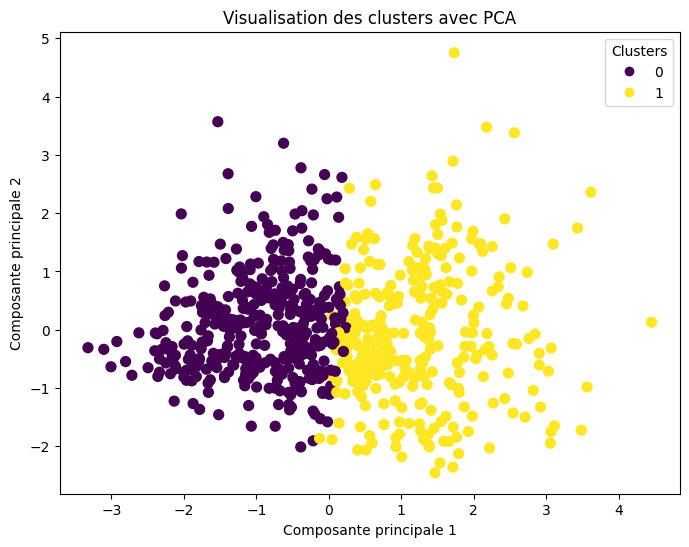

In [9]:
# Réduction à 2 dimensions avec PCA
labels=data_clean_2['cluster']
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Tracé des points colorés par cluster
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50)

# Ajout de la légende
legend = plt.legend(*scatter.legend_elements(), 
                    title="Clusters", 
                    loc="best")

plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.title('Visualisation des clusters avec PCA')
plt.show()


La visualisation nous permet de confirmer que nous avons deux clusters séparés.

In [10]:
# Afficher la part de variance expliquée par PC1 et PC2
print("Variance expliquée par PC1 : {:.2%}".format(pca.explained_variance_ratio_[0]))
print("Variance expliquée par PC2 : {:.2%}".format(pca.explained_variance_ratio_[1]))
print("Variance expliquée cumulée : {:.2%}".format(sum(pca.explained_variance_ratio_)))

Variance expliquée par PC1 : 34.79%
Variance expliquée par PC2 : 20.74%
Variance expliquée cumulée : 55.53%


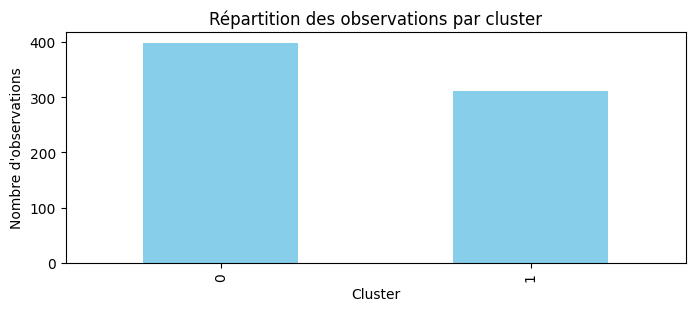

le cluster 0 contient 398 données
le cluster 1 contient 310 données


In [11]:
cluster_counts = data_clean_2['cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 3))
cluster_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Cluster')
plt.ylabel("Nombre d'observations")
plt.title('Répartition des observations par cluster')
plt.show()
print(f"le cluster 0 contient {cluster_counts[0]} données")
print(f"le cluster 1 contient {cluster_counts[1]} données")

Calcul des moyennes pour chaque cluster

In [12]:
moyennes_par_cluster = data_clean_2.groupby('cluster').agg(
    Mean_Glucose=('Glucose', 'mean'),
    Mean_BloodPressure=('BloodPressure', 'mean'),
    Mean_BMI=('BMI', 'mean'),
    Mean_DPF=('DiabetesPedigreeFunction', 'mean'),
    Mean_Age=('Age', 'mean')
)
print(moyennes_par_cluster)

         Mean_Glucose  Mean_BloodPressure   Mean_BMI  Mean_DPF   Mean_Age
cluster                                                                  
0          105.929648           66.804020  29.855779  0.431000  27.351759
1          141.858065           79.709677  35.264194  0.507774  41.261290


Il semble que le cluster 1 est celui à haut risque de diabète avec des valeurs élevées pour le glucose, la pression arterielle, un BMI moye à 35 etc.. et le cluster 0 celui à faible risque